[*********************100%***********************]  1 of 1 completed


Root Mean Squared Error: $2.39


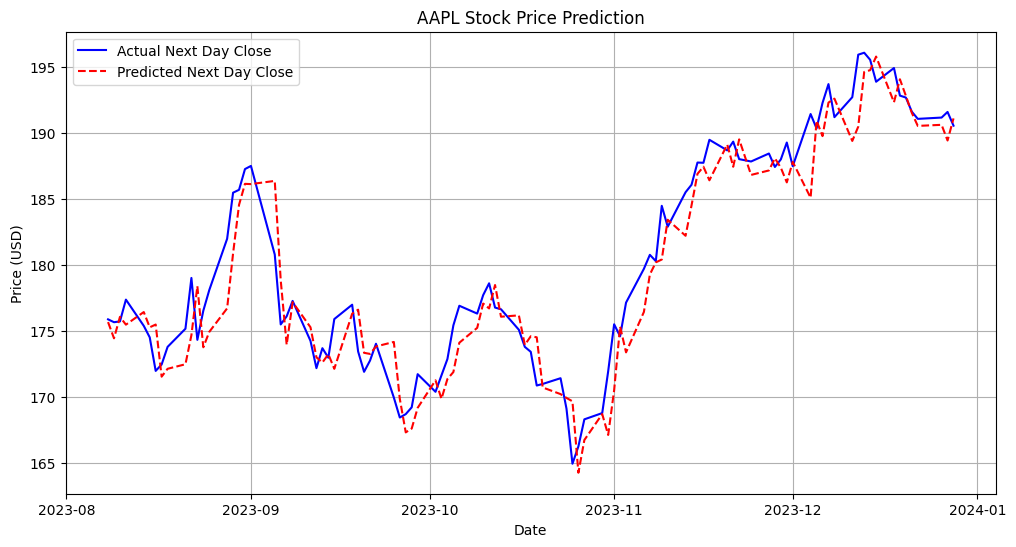

In [1]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# Load historical data using yfinance
df = yf.download("AAPL", start="2022-01-01", end="2024-01-01")

# Create target: predict TOMORROW'S close using TODAY'S features
df["Next_Close"] = df["Close"].shift(-1)
df.dropna(inplace=True)

# Select features and target
X = df[["Open", "High", "Low", "Volume"]]
y = df["Next_Close"]

# Split data sequentially for time series (80% train, 20% test)
split = int(len(df) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Generate predictions
y_pred = model.predict(X_test)

# Calculate RMSE to measure error in USD units
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Root Mean Squared Error: ${rmse:.2f}")

# Plot actual vs predicted prices over time
plt.figure(figsize=(12, 6))
plt.plot(df.index[split:], y_test, label="Actual Next Day Close", color='blue')
plt.plot(df.index[split:], y_pred, label="Predicted Next Day Close", color='red', linestyle='--')
plt.title("AAPL Stock Price Prediction")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()